## Introduction

Standard `matplotlib` markers are perfectly adequate for many graphs, but can feel limiting when creating cool looking infographics or presentation-ready figures. You may have wanted to replace ordinary scatter plot markers with icons representing runners, bicycles, weather conditions, financial trends, or other real-world objects. Unfortunately, `matplotlib` does not provide an obvious way to use custom vector icons directly in plots.

As a result, many Python users resort to manually editing figures in tools like PowerPoint, Illustrator, or Canva after exporting their charts. While this workflow works, it can become tedious when producing multiple figures or iterating on a design.

In this tutorial, I show how to incorporate [Font Awesome icons](https://fontawesome.com/) directly into `matplotlib` figures as either text or path objects. Using icons as text is simple and works well when plotting a handful of icons. For more advanced applications, such as scatter plots, partial icons, or image overlays, converting the icons into paths provides greater flexibility.

### What You'll Learn in this Tutorial

By the end of this blog post, you'll learn how to:

- **Draw Font Awesome icons as text objects** with `matplotlib`'s `.text()` method 
- **Convert Font Awesome icons to paths** for plotting with `matplotlib`'s `.scatter()` method
- Draw a **fraction of an icon** using the `Bbox` class
- Apply an **image overlay to icons** by clipping images to a path or patch object

If you prefer to skip the explanations and jump straight to the implementation, you can [download the code and the data files needed from my GitHub repository](https://github.com/DataDrivenMai/DataDrivenMai-blog/tree/main/python-matplotlib-font-awesome-icons). 

Here is the list of things you'll need to run the code.

### Prerequisites

- A copy of either the `python-matplotlib-font-awesome-icons.ipynb` Jupyter notebook or the `python-matplotlib-font-awesome-icons.py` Python script from my [GitHub repository](https://github.com/DataDrivenMai/DataDrivenMai-blog/tree/main/python-matplotlib-font-awesome-icons)
- Python libraries
	- `numpy`
	- `matplotlib.font_manager`
    - `matplotlib.pyplot`
	- `matplotlib.textpath`
	- `matplotlib.transforms`
	- `matplotlib.path`
	- `matplotlib.patches`
	- `matplotlib.gridspec` (for the .py file)
	- `Pillow`
- A [copy of the `data/` subfolder from my GitHub repository](https://github.com/DataDrivenMai/DataDrivenMai-blog/tree/main/python-matplotlib-font-awesome-icons) containing
    - Three Font Awesome OTF files 
    - Three flag images

### Jargon

**Unicode**: An international standard for character and emoji encoding. It allows screens to display characters, whether it be written in English, French, Japanese or Hebrew. 

**Path**: The `matplotlib.path.Path` object, or objects based on it, such as `matplotlib.textpath.TextPath` object. It consists of path vertices and path codes, the latter of which dictate the nature of the line passing through each vertex. As such, paths are well suited to draw vector type images. See [`matplotlib`'s official documentation on path objects](https://matplotlib.org/stable/api/path_api.html) or [text path objects](https://matplotlib.org/3.5.3/api/textpath_api.html) for more details.

**Patch**: The `matplotlib.patches.Patch` object, defined as a 2D shape with a face and edge color. See [`matplotlib`'s documentation on patch objects](https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Patch.html) for more information.

**Bounding box**: An abstract rectangular boundary in `matplotlib` figures. It can be used to dictate the stylization options of objects contained inside the box.

**Clipping**: A method of restricting the visibility of objects to a specific region within the plot.

## Download the Font Awesome Package for Desktop

There are several methods of installing Font Awesome icons into the Python environment. I find [downloading Font Awesome package for desktop](https://fontawesome.com/download) to the `data/` subdirectory to be quick and intuitive. If you download the free package like I did, you should end up with three OTF files with `'Brands-Regular'`, `'Free-Regular'` and `'Free-Solid'` in the file names. These represent three font packages available in the free version.

Alternatively, if you've downloaded the [`data/` subfolder from my GitHub repository](https://github.com/DataDrivenMai/DataDrivenMai-blog/tree/main/python-matplotlib-font-awesome-icons), you already have a copy of the OTF files at hand.

At the time of writing this blog post (May 2026), the Font Awesome package is version 7.2.0, as indicated by `'Font Awesome 7'` in the three extracted OTF files. If you are downloading after a version update, the file names will differ from the ones I've provided below.

In [39]:
# Path to your downloaded Font Awesome OTF file
font_path_brands = "./data/Font Awesome 7 Brands-Regular-400.otf"
font_path_regular = "./data/Font Awesome 7 Free-Regular-400.otf"
font_path_solid = "./data/Font Awesome 7 Free-Solid-900.otf"

We also need the `matplotlib.font_manager.FontProperties` class to store information about each Font Awesome icon groups.

In [40]:
# Import matplotlib.font_manager
import matplotlib.font_manager as fm

You'll need the font properties of each OTF file to display the icons in each package as text objects, or convert them into path objects.

In [41]:
# Create FontProperties objects for each of the Font Awesome OTF files
fp_brands = fm.FontProperties(fname=font_path_brands)
fp_regular = fm.FontProperties(fname=font_path_regular)
fp_solid = fm.FontProperties(fname=font_path_solid)

We can now choose the icon we'd like to use in our Python projects. 

## Find the Unicode of Your Chosen Icons

To use Font Awesome icons in your Python projects, you will need to know the icon's

- Unicode identifier
- Font package that it belongs to

Both can be found on the [Font Awesome website](https://fontawesome.com). 

The screenshots of the Font Awesome webpages for the two variants of the lightbulb icon, the [regular lightbulb design](https://fontawesome.com/icons/classic/regular/lightbulb) and the [solid lightbulb design](https://fontawesome.com/icons/classic/solid/lightbulb), are shown in @fig-lightbulbs. The Unicode identifier can be found in the top right corner (as indicated by the blue box in the figure), while the Font Awesome font package can be found within the HTML class (as highlighted by the orange box in the figure). The font package is also included in the URL address. You'll notice that the lightbulb icon variants have the same Unicode identifier of `'f0eb'`, but belong to different font packages.

::: {#fig-lightbulbs layout-ncol=2}

![Regular lightbulb icon](./images/lightbulb-regular.png){#fig-lightbulb-regular}

![Solid lightbulb icon](./images/lightbulb-solid.png){#fig-lightbulb-solid}

Unicode identifier (top right blue box) and font package (orange box) for two lightbulb icon variants in Font Awesome.
:::

To use the icons in Python, the escape sequence of `'\u'` will be needed. This indicates that the item we are dealing with is a Unicode identifier. For the lightbulb icons, the Python code will be `'\uf0eb'`.

With the Unicode identifier and the font package of the chosen icon, we can now use them as text objects. 

## Drawing Icons on Plots as Text{#sec-icon-text}

Icons from Font Awesome are treated as characters, each with its own unique Unicode identifier. As such, the simplest method of drawing icons on a plot are to treat them as text objects, specified by their Unicode.

Let's make a simple dictionary containing five icons from the Font Awesome brands package to call each Unicode using a key. Remember to include the `'\u'` Unicode escape sequence.

In [42]:
# Dictionary of five Font Awesome brand icons
fa_dict = {
    "google": "\uf1a0",
	"apple": "\uf179",
	"meta": "\ue49b",
	"amazon": "\uf270",
	"microsoft": "\uf17a"
}

We'll need the `matplotlib.pyplot` library to make the figures to plot the text upon.

In [43]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

Let's place the icons in a figure using `plt.text()`. 

### Minimum Plotting of Icons with `plt.text()`

To draw icons using the `plt.text()` function, we only need the following four arguments:

- x coordinate
- y coordinate
- Unicode identifier
- Appropriate font properties for the chosen icon

Let's see how the Google logo icon looks like with the minimum number of arguments:

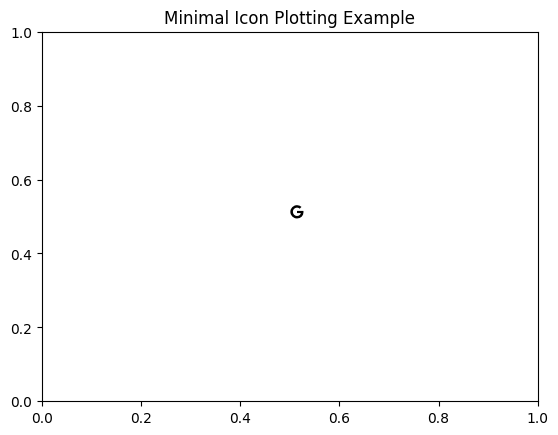

In [44]:
#| label: fig-min
#| fig-cap: "Minimal number of arguments in `plt.text()` draws a small, black icon at the designated coordinates."

# Make a figure with minimal parameters for icon placement
plt.figure()

# Place the Google icon at the center of the plot using the brands font
plt.text(0.5, 0.5, fa_dict["google"], fontproperties=fp_brands)

# Plot logistics
plt.title("Minimal Icon Plotting Example")
plt.show()

A small black icon shows up at the designated location. The default display is rather small, so we'll start by modifying the font size in the next section.

### Change Icon Size with Font Size

The size of the icons can be changed like any text object using the `fontsize` parameter within the `plt.text()` function. You can assign a floating value to indicate a specific font point size. Alternatively, you can specify a relative size such as `'x-small'`. 

Here is a demonstration of the two ways of designating font sizes:

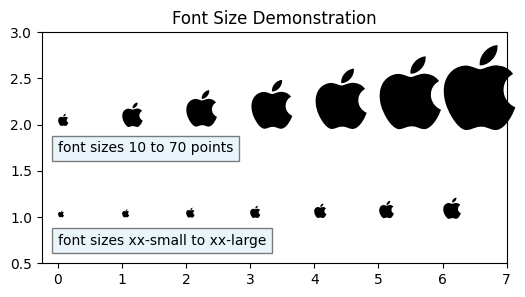

In [45]:
#| label: fig-font-sizes
#| fig-cap: "Icon sizes can be changed by designating either a relative or absolute font size."

# Two different ways of designating font sizes
font_sizes1 = ['xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large']
font_sizes2 = [10, 20, 30, 40, 50, 60, 70]

# Make a figure to demonstrate the different font sizes
plt.figure(figsize=(6, 3))

# Plot the relative and absolute font sizes
for i in range(len(font_sizes1)):
	plt.text(i, 1, fa_dict["apple"], fontproperties=fp_brands, fontsize=font_sizes1[i])
	plt.text(i, 2, fa_dict["apple"], fontproperties=fp_brands, fontsize=font_sizes2[i])

# Description
plt.text(0, 0.7, "font sizes xx-small to xx-large", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0, 1.7, "font sizes 10 to 70 points", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.xlim(-0.25, len(font_sizes1))
plt.ylim(0.5, 3.0)
plt.title("Font Size Demonstration")
plt.show()

To make icons visibly large, you'll most likely designate a point value for its `fontsize` parameter, rather than use the relative sizes. 

Next, let's try changing the color of the icons.

### Change Color of Icons as Text Objects

To change icon colors, simply specify the desired `color` parameter in the `plt.text()` function. There are three useful ways to designate the icon colors.

1. Use named colors like `'red'` or `'blue'`
2. Specify color hex codes like `'#22668D'`
3. Use color gradients such as the ones available with `plt.colormaps`

A demonstration of the three methods are shown:

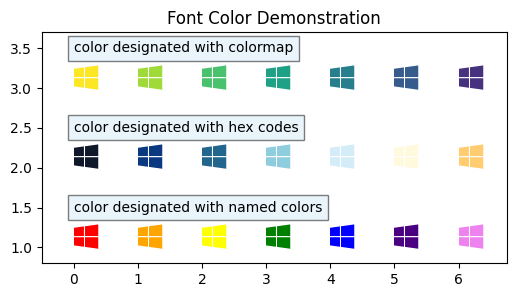

In [46]:
#| label: fig-font-colors
#| fig-cap: "Three ways of specifying font color: named colors, hex codes and colormap values."

# Three types of color specifications
font_colors1 = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'violet']
font_colors2 = ['#0F172A', '#0A3981', '#22668D', '#8ECDDD', '#D4EBF8', '#FFFADD', '#FFCC70']
font_colors3 = plt.colormaps['viridis_r']
icon_size = 20

# Make a figure to demonstrate the different icon colors
plt.figure(figsize=(6, 3))

# Plot the different colors
for i in range(len(font_colors1)):
	plt.text(i, 1, fa_dict["microsoft"], fontproperties=fp_brands, fontsize=icon_size, color=font_colors1[i])
	plt.text(i, 2, fa_dict["microsoft"], fontproperties=fp_brands, fontsize=icon_size, color=font_colors2[i])
	plt.text(i, 3, fa_dict["microsoft"], fontproperties=fp_brands, fontsize=icon_size, color=font_colors3(i/len(font_colors1)))

# Description
plt.text(0, 1.45, "color designated with named colors", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0, 2.45, "color designated with hex codes", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0, 3.45, "color designated with colormap", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.xlim(-0.5, len(font_colors1)-0.25)
plt.ylim(0.8, 3.7)
plt.title("Font Color Demonstration")
plt.show()

We can now change the icon size and color. Next, we'll see how to adjust its rotation angle.

### Change Rotation Angle of Icons as Text Objects

Rotating icons as text objects is as easy as setting a degrees value to the `rotation` parameter in `plt.text()`. Negative values rotate the icon clockwise, while positive values rotate the icon counter-clockwise.

I've shown how the icon looks like rotated in 45° increments from -180° to +180° below:

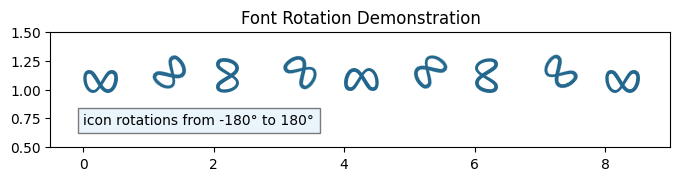

In [47]:
#| label: fig-font-rotation
#| fig-cap: "Setting a `rotation` parameter in the `.text()` method easily rotates the icon."

# Icon rotation angles
icon_rotation = [-180, -135, -90, -45, 0, 45, 90, 135, 180]

# Other parameters of the icon
icon_size = 20
icon_color = '#22668D'

# Make a figure to demonstrate the different rotation angles
plt.figure(figsize=(8, 1.5))

# Plot the different rotations
for i in range(len(icon_rotation)):
	plt.text(i, 1, fa_dict["meta"], fontproperties=fp_brands, fontsize=icon_size, color=icon_color, rotation=icon_rotation[i])
	
# Description
plt.text(0, 0.7, f"icon rotations from {icon_rotation[0]}° to {icon_rotation[-1]}°", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.xlim(-0.5, len(icon_rotation))
plt.ylim(0.5, 1.5)
plt.title("Font Rotation Demonstration")
plt.show()

We can now designate the icon size, color and rotation. Next, we'll look into the details of the placement of text objects.

### Horizontal and Vertical Alignment of Text Objects{#sec-ha-va-text}

Knowing how to draw icons at a designated location with a specific size and color meets most user's needs. Add onto that the power to rotate the icon, and you are already well equipped for most tasks. However, if you need to be exact in the placement of the icons, you will need to know a bit about text alignments. 

Let's start by plotting various brand icons with different sizes, colors and rotation values. We will indicate the exact coordinates where each icon was placed, to see the alignment of text objects relative to the user-specified coordinates.

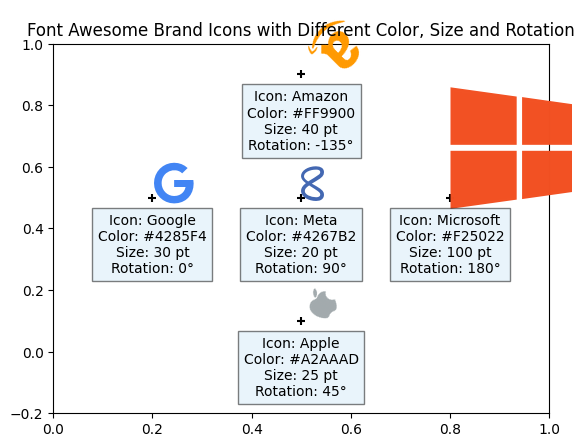

In [48]:
#| label: fig-gafam
#| fig-cap: "Google, Apple, Meta, Amazon and Microsoft icons plotted with different colors, sizes and rotations."

# Designate the icons to plot
icons = ["google", "apple", "meta", "amazon", "microsoft"]

# Designate the locations for each icon
xLoc = [0.2, 0.5, 0.5, 0.5, 0.8]
yLoc = [0.5, 0.1, 0.5, 0.9, 0.5]

# Specify color, size and rotation for each icon
icon_colors = ['#4285F4', '#A2AAAD', '#4267B2', '#FF9900', '#F25022']
font_sizes = [30, 25, 20, 40, 100]
icon_rotation = [0, 45, 90, -135, 180]

# Plot the figure with all the icons, colors, sizes and rotations
plt.figure()

for i in range(len(icons)):
    plt.text(xLoc[i], yLoc[i], fa_dict[icons[i]], fontproperties=fp_brands, color=icon_colors[i], fontsize=font_sizes[i], rotation=icon_rotation[i])
    
	# Scatter plot of icon locations
    plt.scatter(xLoc[i], yLoc[i], color='black', marker='+')

	# Description
    describe_now = f"Icon: {icons[i].capitalize()}\nColor: {icon_colors[i]}\nSize: {font_sizes[i]} pt\nRotation: {icon_rotation[i]}°"
    plt.text(xLoc[i], yLoc[i] - 0.05, describe_now, ha='center', va='top', fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Set the details of the plot before showing
plt.title("Font Awesome Brand Icons with Different Color, Size and Rotation")
plt.xlim(0, 1)
plt.ylim(-0.2, 1)
plt.show()

The coordinates where each icon was placed are indicated with a small black '+'. We see that the default is to align the lower left corner of the icons to the user specified coordinates. 

Vertical and horizontal alignment of text objects relative to the designated coordinates can be adjusted by specifying the `'va'` (vertical alignment) and `'ha'` (horizontal alignment) parameters. There are five options for vertical alignment: `'baseline'`, `'bottom'`, `'center'`, `'center_baseline'`, and `'top'`, and three possible options for horizontal alignment: `'left'`, `'center'`, and `'right'`. 

The code below demonstrates how these different options show up on the plot. 

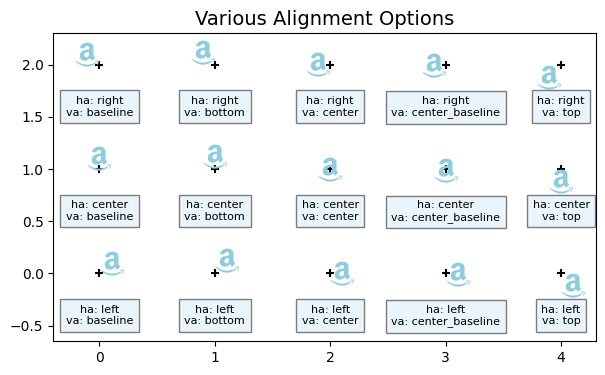

In [49]:
#| label: fig-alignment
#| fig-cap: "Fifteen different combinations of horizontal and vertical alignments."

# Various vertical and horizontal alignments to test
icon_va = ['baseline', 'bottom', 'center', 'center_baseline', 'top']
icon_ha = ['left', 'center', 'right']

# Other variables
icon_color = '#8ECDDD'

# Create figure
plt.figure(figsize=(7, 4))

# Plot the icons with different horizontal and vertical alignments
for i in range(len(icon_va)):
	for j in range(len(icon_ha)):
		plt.text(i, j, fa_dict["amazon"], fontproperties=fp_brands, fontsize=20, color=icon_color, ha=icon_ha[j], va=icon_va[i])
		plt.text(i, j - 0.3, f'ha: {icon_ha[j]}\nva: {icon_va[i]}', fontsize=8, ha='center', va='top', bbox=dict(facecolor='#D4EBF8', alpha=0.5))
		plt.scatter(i, j, color='black', marker='+')

# Plot logistics
plt.xlim(-0.4, len(icon_va)-0.7)
plt.ylim(-0.65, len(icon_ha)-0.7)
plt.title("Various Alignment Options", fontsize=14)
plt.show()

Some of the vertical alignment options are quite similar. For example `'baseline'` is only slightly higher than `'bottom'`, and `'center_baseline'` looks to be a tiny bit higher than `'center'`. Perhaps the difference is more noticeable when working with larger icon sizes. 

We have covered the most useful features of drawing Font Awesome icons as text objects. You can also refer to the [`matplotlib` documentation on `pyplot.text()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.text.html) for information on how to further customize icons as text.

Plotting icons as text objects is quite simple and will be sufficient for most users. However, it has its quirks. For example, you may notice in @fig-gafam that text objects are always placed on top of scatter plot markers, regardless of the placement order. Additionally, text objects can flow outside the axis limits. If you want to contain the icons within the axis limits, converting them as paths and scatter plotting them may be a better option.

## Drawing Icons on Plots as Paths{#sec-icon-path}

Converting Font Awesome icons into path objects allow us greater flexibility. We can use paths as markers for scatter plots. This will automatically keep plotted icons within the axes limits, allow the user to specify different marker edge and face colors, or modify the paths before plotting them. Additionally, once a path is created from the icon, we no longer need to remember the font properties to plot them.

To change things up, we'll add a couple new entries into the dictionary.

In [50]:
# Add a couple new entries to the dictionary
fa_dict.update({"fire": '\uf7e4',
                "moon": '\uf186', 
                "star": '\uf005'})

### Convert Icons to Paths

As explained before, Font Awesome icons are treated like fancy text objects. To convert these into paths, we'll use the TextPath class from `matplotlib.textpath`. Refer to the [`matplotlib` documentation on `textpath.TextPath`](https://matplotlib.org/3.5.3/api/textpath_api.html#matplotlib.textpath.TextPath) if you are interested in the details.


In [ ]:
# Import matplotlib.textpath module
import matplotlib.textpath as mtextpath

To convert a Font Awesome icon from a text to a path using `matplotlib.textpath.TextPath()`, we require the following:

- Offset position of the text
- Unicode identifier
- Font properties of the text used

Let's create two variants of the star icon with `mtextpath.TextPath()`:

In [52]:
# Convert the two variants of the star icon to TextPath object
star_reg_path = mtextpath.TextPath((0, 0), fa_dict["star"], prop=fp_regular)
star_solid_path = mtextpath.TextPath((0, 0), fa_dict["star"], prop=fp_solid)

We now have two paths: `star_reg_path` which is an outline of a star, and `star_solid_path`, which is star icon with a solid fill. 

Let's try plotting them in scatter plots.

### Change Marker Size and Color in Scatter Plots

The generated path can be used as a marker in the `plt.scatter()` function. Aside from the coordinates of the scatter plot, the marker size and color can be specified with `s` and `color` parameters, respectively. The `marker` parameter is assigned with one of the two star paths generated above. 

Below is a demonstration of `plt.scatter()` using the paths generated from the two star icons as the `marker` parameter. The marker size is specified with the different sizes in the `marker_size` list. The marker color is specified with the three methods, as before: 

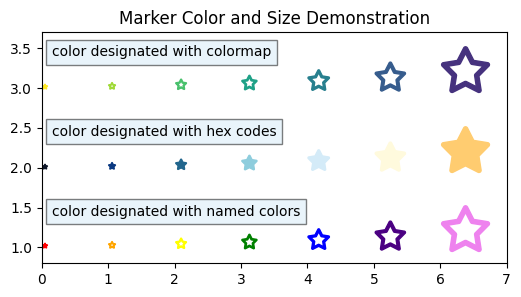

In [53]:
#| label: fig-path-color-size
#| fig-cap: "Icons plotted using `.scatter()` method with different marker sizes and colors."

# Modify marker size and color
marker_size = [50, 100, 250, 500, 1000, 2000, 5000]
icon_colors1 = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'violet']
icon_colors2 = ['#0F172A', '#0A3981', '#22668D', '#8ECDDD', '#D4EBF8', '#FFFADD', '#FFCC70']
icon_colors3 = plt.colormaps['viridis_r']

# Generate a figure
plt.figure(figsize=(6, 3))

# Generate the stars with the plt.scatter function
for i in range(0, len(marker_size)):
	plt.scatter(i, 1, color=icon_colors1[i], marker=star_reg_path, s=marker_size[i])
	plt.scatter(i, 2, color=icon_colors2[i], marker=star_solid_path, s=marker_size[i])
	plt.scatter(i, 3, color=icon_colors3(i/len(marker_size)), marker=star_reg_path, s=marker_size[i])

# Description
plt.text(0.15, 1.4, "color designated with named colors", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0.15, 2.4, "color designated with hex codes", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0.15, 3.4, "color designated with colormap", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.xlim(0, len(marker_size))
plt.ylim(0.8, 3.7)
plt.title("Marker Color and Size Demonstration")
plt.show()

Just like with text objects, color can be designated with named colors, using hex codes, or using a colormap. 

But that's not all the color options available with scatter plots. With `plt.scatter()`, we can specify different colors for the marker face and the marker edge. 

### Use Different Icon Edge and Face Colors{#sec-edgecolor}

We specified the marker color with the `color` parameter in `plt.scatter()`. We can further specify the marker `edgecolor` with one of three options. The `'face'` option gives the same edge color as the marker face. The `'none'` option removes the edge line altogether. Alternatively, you can specify an edge color with named colors or hex codes.  

In the example below, we show the three `edgecolor` options on the solid star icon. The `linewidth` parameter has been set to 5 to make the differences more noticeable between the `'none'` option and the others.

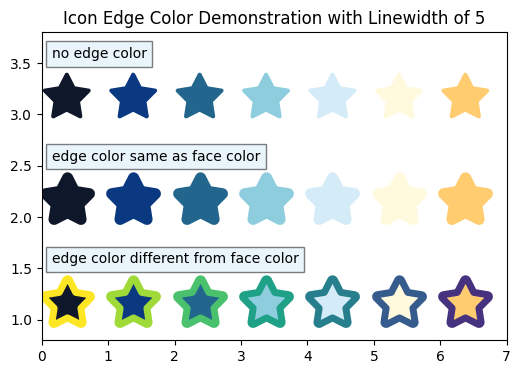

In [54]:
#| label: fig-edgecolors
#| fig-cap: "Three marker edge color options available with the scatter plot."

# Modify size and color
marker_size = 5000
icon_colors = ['#0F172A', '#0A3981', '#22668D', '#8ECDDD', '#D4EBF8', '#FFFADD', '#FFCC70']
edge_colors = plt.colormaps['viridis_r']
edge_width = 5

# Generate a figure
plt.figure(figsize=(6, 4))

# Generate the stars with the plt.scatter function
for i in range(0, len(icon_colors)):
	plt.scatter(i, 1, color=icon_colors[i], marker=star_solid_path, s=marker_size, edgecolor=edge_colors(i/len(icon_colors)), linewidth=edge_width)
	plt.scatter(i, 2, color=icon_colors[i], marker=star_solid_path, s=marker_size, edgecolor='face', linewidth=edge_width)
	plt.scatter(i, 3, color=icon_colors[i], marker=star_solid_path, s=marker_size, edgecolor='none', linewidth=edge_width)
	
# Description
plt.text(0.15, 1.55, "edge color different from face color", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0.15, 2.55, "edge color same as face color", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0.15, 3.55, "no edge color", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.title(f"Icon Edge Color Demonstration with Linewidth of {edge_width}")
plt.xlim(0, len(icon_colors))
plt.ylim(0.8, 3.8)
plt.show()

The top row in @fig-edgecolors shows how setting `edgecolor='none'` keeps the icons sharp-looking at the star points. On the other hand, the middle row shows that specifying `edgecolor='face'` can give a rounded impression to the icons. Assigning a different edge color as the face color gives a unique impression, as seen in the bottom row.

We can now designate the position of the icon as a marker, its color (`color` parameter), and its size (`s` parameter). The creative flexibility of `edgecolor` and `linewidth` are features of `.scatter()` method that were not available with the text options. 

However, when it comes to rotating markers, `plt.scatter()` does not have this particular functionality. But do not fret; there is a workaround. We can create a path with a preset rotation angle, and plot that.

### Rotate Paths to Rotate Markers

To rotate paths, we need the `matplotlib.transforms` module:

In [55]:
# Import matplotlib.transforms to use Affine_2D
import matplotlib.transforms as mtransforms

We can use the `mtransforms.Affine2D().rotate_deg()` to create a rotation type of transformation, then apply this to the original path using `path_name.transformed(transform_type)`. 

The result of marker rotation with `mtransforms.Affine2D().rotate_deg()` is demonstrated below:

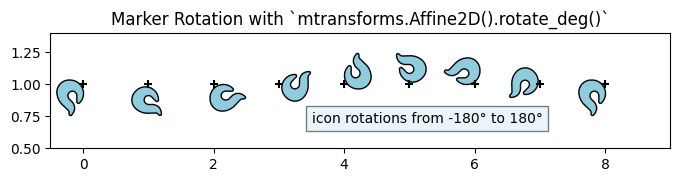

In [ ]:
#| label: fig-path-rotation
#| fig-cap: "Rotating paths with `mtransforms.Affine2D().rotate_deg()` rotates the icon around the placement marker."

# Generate a default path with no rotation
fire_path_default = mtextpath.TextPath((0, 0), fa_dict["fire"], prop=fp_solid)

# Marker rotation angles
icon_rotation = [-180, -135, -90, -45, 0, 45, 90, 135, 180]

# Other icon parameters
icon_size = 2000
icon_color = '#8ECDDD'
edge_color = 'black'

# Make a figure to demonstrate the different rotation angles
plt.figure(figsize=(8, 1.5))

# Plot the various rotation angles
for i in range(len(icon_rotation)):
	# Generate a path with rotation using mtransforms.Affine2D().rotate_deg()
	rot_transform = mtransforms.Affine2D().rotate_deg(icon_rotation[i])
	fire_path_rot = fire_path_default.transformed(rot_transform)
		
	# Scatter plot of icon and a '+' to mark the spot
	plt.scatter(i, 1, color=icon_color, marker=fire_path_rot, s=icon_size, edgecolors=edge_color)
	plt.scatter(i, 1, color='black', marker='+')
	
# Description
plt.text(3.5, 0.7, f"icon rotations from {icon_rotation[0]}° to {icon_rotation[-1]}°", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.xlim(-0.5, len(icon_rotation))
plt.ylim(0.5, 1.4)
plt.title("Marker Rotation with `mtransforms.Affine2D().rotate_deg()`")
plt.show()

Unlike the text objects from before, icons as paths are rotated around the (0, 0) position marked by the '+'. This affects the alignment and positioning of the marker when plotting them.

We can rotate an icon "on the spot" using `mtransforms.Affine2D().rotate_deg_around()`. The center point of the icon will need to be calculated using the maximum and minimum values of the path vertices.

Let's see how this would look like:

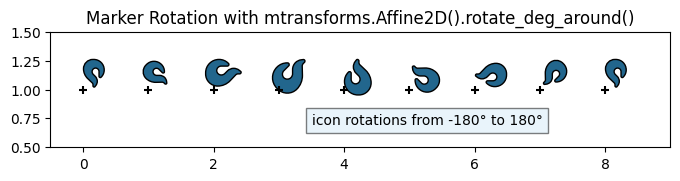

In [ ]:
#| label: fig-path-rotation-around
#| fig-cap: "Rotating paths with `mtransforms.Affine2D().rotate_deg_around()` rotates the icon on the spot."

# Generate a default path with no rotation
fire_path_default = mtextpath.TextPath((0, 0), fa_dict["fire"], prop=fp_solid)

# Marker rotation angles
icon_rotation = [-180, -135, -90, -45, 0, 45, 90, 135, 180]

# Other icon parameters
icon_size = 2000
icon_color = '#22668D'
edge_color = 'black'

# Make a figure to demonstrate the rotation angles on the spot
plt.figure(figsize=(8, 1.5))

# Plot the various rotation angles
for i in range(len(icon_rotation)):
	# Calculate the center point
	max_x, max_y = fire_path_default.vertices.max(axis=0)
	min_x, min_y = fire_path_default.vertices.min(axis=0)
	mid_x = (max_x - min_x) / 2
	mid_y = (max_y - min_y) / 2

	# Generate a path with rotation using mtransforms.Affine2D().rotate_deg_around()
	rot_transform_around = mtransforms.Affine2D().rotate_deg_around(mid_x, mid_y, icon_rotation[i])
	fire_path_rot = fire_path_default.transformed(rot_transform_around)
	
	# Scatter plot of icon and a '+' to mark the spot
	plt.scatter(i, 1, color=icon_color, marker=fire_path_rot, s=icon_size, edgecolors=edge_color)
	plt.scatter(i, 1, color='black', marker='+')
	
# Description
plt.text(3.5, 0.7, f"icon rotations from {icon_rotation[0]}° to {icon_rotation[-1]}°", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.xlim(-0.5, len(icon_rotation))
plt.ylim(0.5, 1.5)
plt.title("Marker Rotation with mtransforms.Affine2D().rotate_deg_around()")
plt.show()

We can see the icon has been successfully rotated on the spot, with the placement marker remaining on the lower left corner of the marker. 

In the next section, we will work on modifying the position of this placement marker. 

### Greater Precision in Horizontal and Vertical Alignment{#sec-precise-alignment}

We saw that [text objects have various horizontal vertical alignment options](#sec-ha-va-text). Specifically, @fig-alignment showed fifteen different alignment options available with text objects. 

Alignment options are not available in the `plt.scatter()` function, but can be specified during the creation of the path objects with `textpath.TextPath` class. By specifying x and y coordinate offsets along with a `size` argument, we can designate how icons will be aligned and placed relative to the user specified coordinates during the `plt.scatter()` function call.

Do note that the marker `s` (size) parameter in `plt.scatter()` is the biggest factor determining final icon size. In that regard, the size specified during path generation does not affect the plotted marker as much. However, the path size interacts with the offset values, affecting how they are drawn in the final plot. 

We will show how the two interact in the final display:

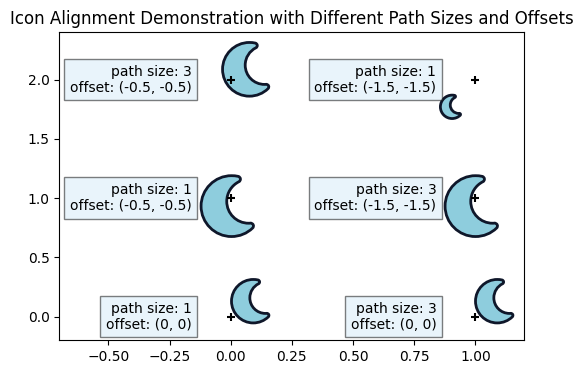

In [58]:
#| label: fig-path-six-alignments
#| fig-cap: "Path size and offsets affect the final marker size and alignment."

# Make several moon icons with different size and offset coordinates 
offset_xy = [[(0, 0), (0, 0)], 
             [(-0.5, -0.5), (-1.5, -1.5)], 
             [(-0.5, -0.5), (-1.5, -1.5)]] 
path_size = [[1, 3], 
             [1, 3], 
             [3, 1]]

# Modify size and color
marker_size = 3000
icon_faceCol = '#8ECDDD'
icon_edgeCol = '#0F172A'
edge_width = 2

# Generate a figure
plt.figure(figsize=(6, 4))

# Generate the moon with the plt.scatter function
for i in range(0, len(offset_xy)):
	for j in range(0, len(offset_xy[0])):
		# Make path with user-specified size and offset_xy
		moon_path_align = mtextpath.TextPath(offset_xy[i][j], fa_dict["moon"], prop=fp_solid, size=path_size[i][j])

		# Scatter plot
		plt.scatter(j, i, color=icon_faceCol, marker=moon_path_align, s=marker_size, edgecolor=icon_edgeCol, linewidth=edge_width)
		plt.scatter(j, i, color='black', marker='+')
		
		# Description
		plt.text(j-0.16, i, f"path size: {path_size[i][j]}\noffset: {offset_xy[i][j]}", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5), ha='right', va='center')

# Plot logistics
plt.title("Icon Alignment Demonstration with Different Path Sizes and Offsets")
plt.xlim(-0.7, 1.2)
plt.ylim(-0.2, 2.4)
plt.show()

As seen in the bottom row of @fig-path-six-alignments, an offset of `(0, 0)` makes identical markers regardless of the size used in the path generation. The middle row shows that specifying a negative offset of `(-0.5, -0.5)` for the path size of `1` creates a path identical to a path with three times its size and offset (size of `3` and a negative offset of `(-1.5, -1.5)`). The top row shows how paths generated with the same offset as the middle row, but different path sizes result in a different placement pattern as any of the other icons.

Below, we create nine icons with the same path size, but different offsets.

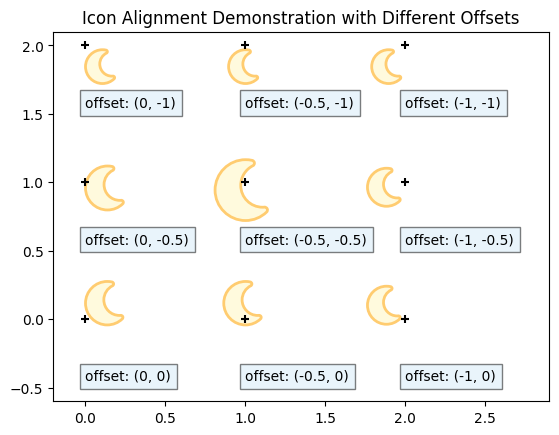

In [59]:
#| label: fig-path-align
#| fig-cap: "Path offsets half the magnitude of path size does not necessarily place the alignment marker in the center of the icon."

# User specified marker size and alignment
offset_xy2 = [[(0, 0), (-0.5, 0), (-1, 0)], 
			  [(0, -0.5), (-0.5, -0.5), (-1, -0.5)], 
			  [(0, -1), (-0.5, -1), (-1, -1)]]
path_size2 = 1

# Modify size and color
marker_size = 3000
icon_faceCol = '#FFFADD'
icon_edgeCol = '#FFCC70'
edge_width = 2

# Generate a figure
plt.figure()

# Generate the moon with the plt.scatter function
for i in range(0, len(offset_xy2)):
	for j in range(0, len(offset_xy2[0])):
		# Generate a path with the user defined size and alignment
		moon_path_align = mtextpath.TextPath(offset_xy2[i][j], fa_dict["moon"], prop=fp_solid, size=path_size2)
		
		# Scatter plot
		plt.scatter(j, i, color=icon_faceCol, marker=moon_path_align, s=marker_size, edgecolor=icon_edgeCol, linewidth=edge_width)
		plt.scatter(j, i, color='black', marker='+')
		
		# Description
		plt.text(j, i-0.45, f"offset: {offset_xy2[i][j]}", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.title("Icon Alignment Demonstration with Different Offsets")
plt.xlim(-0.2, 2.9)
plt.ylim(-0.6, 2.1)
plt.show()

While an offset with half the magnitude of the path size seems to be roughly the mid-point of the icon, it is not quite dead center. This is most likely because the TextPath object does not fill the maximum available area. 

However, this can be easily fixed.

I've provided a function below called `CreateAlignedIcon()`. This function can adjust the placement coordinates precisely as a fraction of the whole length of the icon. Specifying a `h_align` parameter of 0.5 will hit the center point in the horizontal axis, while designating 0.6 to `v_align` will put the placement marker of the icon just above the halfway mark. The placement marker will be at 60 % of the icon height, to be exact. 

Since this function requires the `matplotlib.textpath`, `matplotlib.path` and `numpy` modules, we'll import these first. 

In [ ]:
# Import modules 
# import matplotlib.textpath as mtextpath # Already imported
import matplotlib.path as mpath
import numpy as np

In [61]:
def CreateAlignedIcon(icon_unicode, icon_font_prop, h_align, v_align, path_size):
    """Function to generate a path from the icon unicode with specified horizontal and vertical alignments. Requires matplotlib.path (as mpath), matplotlib.textpath (as mtextpath) and numpy (as np) to be imported.
    AUTHOR:     Mai Tanaka (www.DataDrivenMai.com)
    DATE:       2026-05-11
    REQUIRES:   icon_unicode = unicode for the icon (eg. '\uf005' for the star icon in Font Awesome)
                icon_font_prop = matplotlib.font_manager.FontProperties object for the icon 
                h_align = horizontal alignment (0 = left, 0.5 = center, 1 = right)
                v_align = vertical alignment (0 = bottom, 0.5 = center, 1 = top)
                path_size = path size when generating
    RETURNS:    final_path = a matplotlib.path.Path object with the specified alignments
    """
    
	# Create the initial TextPath to check its max and min values
    test_path = mtext.TextPath((0, 0), icon_unicode, prop=icon_font_prop, size=path_size)

	# Extract the vertices and codes from the test_path
    test_vertices = test_path.vertices
    test_codes = test_path.codes

	# Calculate the max and min coordinates of the icon path
    max_x, max_y = test_path.vertices.max(axis=0)
    min_x, min_y = test_path.vertices.min(axis=0)

	# Calculate the correctional offset required to obtain the desired alignment
    diff_x = max_x - min_x
    diff_y = max_y - min_y
    offset_x = diff_x * h_align
    offset_y = diff_y * v_align
    
	# Resize to make the largest side of the icon=path_size
    if (diff_x > diff_y):
        resize_fac = path_size / diff_x
    else:
        resize_fac = path_size / diff_y

	# Calculate the new vertices by applying the offsets and resizing
    new_vertices = np.zeros_like(test_vertices)
    new_vertices[:, 0] = (test_vertices[:, 0] - min_x - offset_x) * resize_fac 
    new_vertices[:, 1] = (test_vertices[:, 1] - min_y - offset_y) *  resize_fac

	# Create the final path with the new vertices and original code
    final_path = mpath.Path(new_vertices, test_codes)

	# Return the final path
    return final_path

Let's try drawing a scatter plot with icon paths generated with this new function:

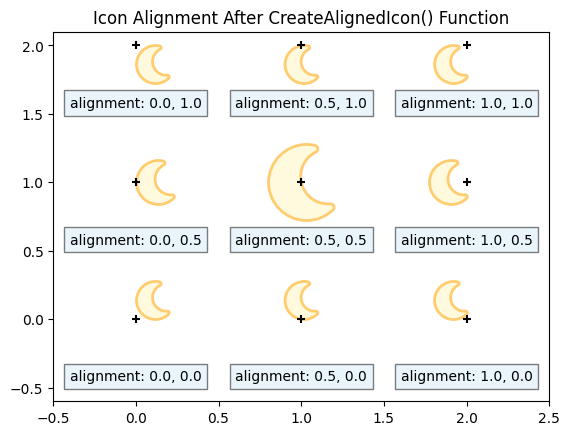

In [62]:
#| label: fig-align-after
#| fig-cap: "The `CreateAlignedIcon()` function successfully places the alignment marker at the center of the icon."

# List of horizontal and vertical alignments to test with path size of 1
path_size = 1
icon_halign = [[0.0, 0.5, 1.0], 
			   [0.0, 0.5, 1.0],
			   [0.0, 0.5, 1.0]]
icon_valign = [[0.0, 0.0, 0.0], 
			   [0.5, 0.5, 0.5],
			   [1.0, 1.0, 1.0]]

# Specify size and color for the icons
marker_size = 3000
icon_faceCol = '#FFFADD'
icon_edgeCol = '#FFCC70'
edge_width = 2

# Generate a figure
plt.figure()

# Generate the moon with the plt.scatter function
for i in range(0, len(icon_halign)):
	for j in range(0, len(icon_halign[0])):
		# Generate the icon with the CreateAlignedIcon function and plot it with plt.scatter
		icon_path = CreateAlignedIcon(fa_dict["moon"], fp_solid, icon_halign[i][j], icon_valign[i][j], path_size)

		# Scatter plot of the icon and a '+' to mark the spot
		plt.scatter(j, i, color=icon_faceCol, marker=icon_path, s=marker_size, edgecolor=icon_edgeCol, linewidth=edge_width)
		plt.scatter(j, i, color='black', marker='+')
		
		# Description
		plt.text(j, i-0.45, f"alignment: {icon_halign[i][j]}, {icon_valign[i][j]}", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5), ha='center')

# Plot logistics
plt.title("Icon Alignment After CreateAlignedIcon() Function")
plt.xlim(-0.5, 2.5)
plt.ylim(-0.6, 2.1)
plt.show()

We can now plot the icons with better alignment than before. The vertical and horizontal alignments are specified as a fraction with `(0, 0)` being the lower left corner and `(1, 1)` being the top right corner. 

The advantage of this function is that we can now incrementally adjust the alignment. Below, we see how the icons look when the vertical alignment is kept constant and the horizontal alignment is incremented by 0.2. 

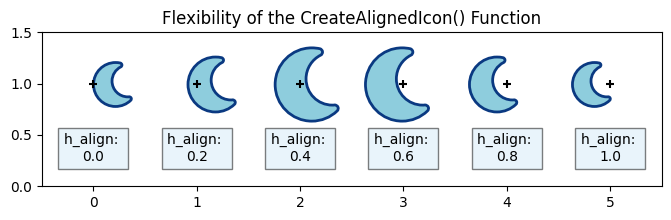

In [ ]:
#| label: fig-align-precise
#| fig-cap: "The `CreateAlignedIcon()` function allows for precise adjustment of the icon alignment."

# List of horizontal and vertical alignments to test
path_size = 1
icon_valign =  0.5
icon_halign = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# Specify size and color for the icons
marker_size = 3000
icon_faceCol = '#8ECDDD'
icon_edgeCol = '#0A3981'
edge_width = 2

# Generate a figure
plt.figure(figsize=(8, 2))

# Generate the moon icon with the plt.scatter function
for i in range(0, len(icon_halign)):
	# Generate the icon with the CreateAlignedIcon function and plot it with plt.scatter
	icon_path = CreateAlignedIcon(fa_dict["moon"], fp_solid, icon_halign[i], icon_valign, path_size)

	# Scatter plot of the icon and a '+' to mark the spot
	plt.scatter(i, 1, color=icon_faceCol, marker=icon_path, s=marker_size, edgecolor=icon_edgeCol, linewidth=edge_width)
	plt.scatter(i, 1, color='black', marker='+')
	
	# Description
	plt.text(i, 0.25, f"h_align: \n{icon_halign[i]}", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5), ha='center')

# Plot logistics
plt.title("Flexibility of the CreateAlignedIcon() Function")
plt.xlim(-0.5, len(icon_halign) - 0.5)
plt.ylim(0, 1.5)
plt.show()

In this manner, the `CreateAlignedIcon()` function can manage small modifications in the horizontal and vertical icon alignments. This feature was not available when plotting the icons as text objects. Keep in mind that the icon sizes vary depending on the location of the horizontal and vertical alignment coordinates. For now, we can adjust this with the marker size when calling the `plt.scatter()` function. 

We are now able to plot Font Awesome icons in `matplotlib` figures as text or path objects with the user's designated coordinates, icon size, icon color, rotation angle and horizontal and vertical alignments. 

In the next sections, I'll show you a couple more features available to icons converted into paths, aside from [using different colors for the face and edge of the icons](#sec-edgecolor), and [precisely manipulating vertical and horizontal alignments of the icons](#sec-precise-alignment). Namely, drawing only part of an icon, and overlaying an image on top of the icon. 

But first, let's add a couple new icons to the dictionary.  

In [64]:
# Add a couple new entries to the dictionary
fa_dict.update({"heart": '\uf004', 
                "walk": '\uf554',
                "bicycle": '\uf206', 
                "car": '\uf5e4',
                "bus": '\ue81d',
               "flag": '\uf2b4'})

I'll start by showing how to plot a fraction of an icon.

## Plotting Part of an Icon 

You may encounter a situation where you want to show an icon, but only part of it. Perhaps you're creating a graphic showing parts of a whole, or a bar graph where a full icon represents hundreds or thousands in numbers. Maybe you come across an icon design you like, but only need the right or left half of it. 

In this section, I will show you how to use a bounding box, or `Bbox` in `matplotlib.transforms`, to designate the part of the icon to show. 

To show part of a Font Awesome icon: 

1. Create a path from a Font Awesome icon using `CreateAlignedIcon()` function
2. Create an imaginary box using `mtransforms.Bbox.from_extents(x_min, y_min, x_max, y_max)`
3. Superimpose the bounding box onto the path created in step one using `path.clip_to_bbox(bbox)`.

Let's plot heart icons like the health gauge in a role-playing game.

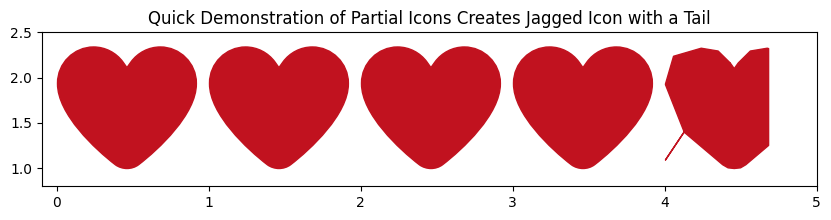

In [65]:
#| label: fig-heart-initial
#| fig-cap: "Two issues encountered when plotting partial icons: rough-looking icon outlines and tail-like extra lines."

# Use CreateAlignedIcon to create a path for the heart icon
path_size = 1
heart_path1 = CreateAlignedIcon(fa_dict['heart'], fp_solid, 0, 0, path_size)

# Define a bounding box for clipping with x_min, y_min, x_max, y_max coordinates
bbox1 = mtransforms.Bbox.from_extents(0, 0, 0.75*path_size, 1*path_size)

# Clip the path to the Bbox
# Set inside=True to show the inside of the box, and inside=False to show the outside of the box
clipped_heart_path1 = heart_path1.clip_to_bbox(bbox1, inside=True)

# Set the marker size
marker_size = 40000
icon_color = '#C1121F'
edge_color = 'face'

# Plot the hearts
plt.figure(figsize=(10, 2))

# Plot four full hearts
for i in range(0, 4):
    plt.scatter(i, 1, marker=heart_path1, s=marker_size, color=icon_color, edgecolors=edge_color)
    
# Plot three-quarters of a full heart_path
new_marker_size = marker_size * 0.75
plt.scatter(4, 1, marker=clipped_heart_path1, s=new_marker_size, color=icon_color, edgecolors=edge_color)

# Plot logistics
plt.xlim(-0.1, 5)
plt.ylim(0.8, 2.5)
plt.title('Quick Demonstration of Partial Icons Creates Jagged Icon with a Tail')
plt.show()

While we've successfully showed part of the heart icon, we see two issues:

- The heart icon has a little "tail" hanging out from the lower left
- The edges of the heart icon look rather jagged.

The issue with the "tail" has to do with the path vertices. Font Awesome paths designate their vertices to divert to an "origin point". It is prominent in more complex shapes, where the path vertices regularly visit this origin.

I'll draw a line plot connecting the vertices of the bike icon path to show what I mean:

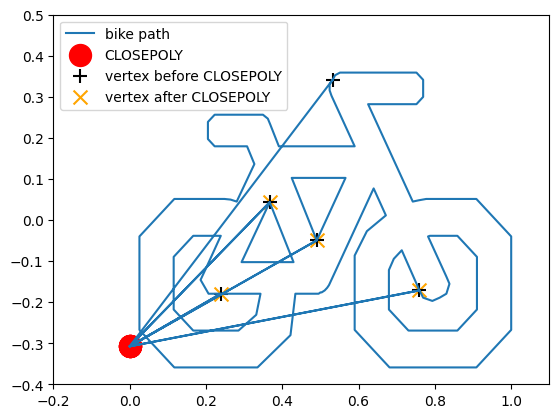

In [66]:
#| label: fig-tail
#| fig-cap: "The icon vertices includes an arbitrary origin to close the path, which shows up as extra lines in the partial plots of icons."

# Create the bike icon path
path_size = 1
bike_path = CreateAlignedIcon(fa_dict['bicycle'], fp_solid, 0, 0.5, path_size)

# We'll be using the path vertices and path codes
path_vertices = bike_path.vertices
path_codes = bike_path.codes

# Make a figure
plt.figure()

# Plot the bike path vertices
plt.plot(bike_path.vertices[:, 0], bike_path.vertices[:, 1])

# Plot the location where code is 79 (CLOSEPOLY)
for i in range(0, len(path_codes)):
    if (path_codes[i] == 79):
        # Plot the point with code 79 and those points before and after
        plt.scatter(path_vertices[i, 0], path_vertices[i, 1], c='red', marker='o', s=250)
        plt.scatter(path_vertices[i-1, 0], path_vertices[i-1, 1], c='black', marker='+', s=100)
        if (i != (len(path_codes)-1)):
             plt.scatter(bike_path.vertices[i+1, 0], bike_path.vertices[i+1, 1], c='orange', marker='x', s=100)
    
# Plot logistics
plt.xlim([-0.2, 1.1])
plt.ylim([-0.4, 0.5])
plt.legend(['bike path', 'CLOSEPOLY', 'vertex before CLOSEPOLY', 'vertex after CLOSEPOLY'])
plt.show()

These extra lines to the vertices where the path code is equal to `CLOSEPOLY = np.uint8(79)` is what is showing up as the "tail" in the heart. 

The solution I've found is to set `edgecolor='None'`. The extra lines in the paths only show up when we've:

- Clipped the path to some bounding box, AND
- The path `edgecolor` is not set to `'None'`

As long as one of these two conditions are not fulfilled, the drawn icon should look fine.

For the second issue or rough looking edges, I've found out (completely by chance) that the fix is to use a very large path size when converting from a text to a path object. In our case, `path_size` is a parameter in the `CreateAlignedIcon()` function. The partial heart will look much smoother when we increase path size from 1 to 100. 

Let's see how the same figure looks when we've addressed these two issues:

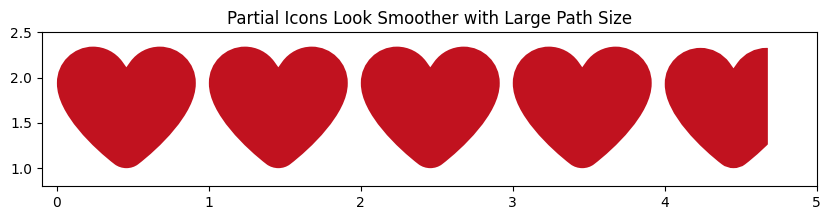

In [ ]:
#| label: fig-heart-clean
#| fig-cap: "Use a large path size and `edgecolor='None'` to resolve the issues of jagged looking lines and tail-like extra lines."

# Use CreateAlignedIcon to create a path for the heart icon
path_size = 100
heart_path2 = CreateAlignedIcon(fa_dict['heart'], fp_solid, 0, 0, path_size)

# Define a bounding box for clipping with x_min, y_min, x_max, y_max coordinates
bbox2 = mtransforms.Bbox.from_extents(0, 0, 0.75*path_size, 1*path_size)

# Clip the path to the Bbox
# Set inside=True to show the inside of the box, and inside=False to show the outside of the box
clipped_heart_path2 = heart_path2.clip_to_bbox(bbox2, inside=True)

# Set the marker size
marker_size = 40000
icon_color = '#C1121F'
edge_color = 'None'

# Plot the hearts
plt.figure(figsize=(10, 2))

# Plot four full hearts
for i in range(0, 4):
    plt.scatter(i, 1, marker=heart_path2, s=marker_size, color=icon_color, edgecolors=edge_color)
    
# Plot three-quarters of a full heart_path
new_marker_size = marker_size * 0.75
plt.scatter(4, 1, marker=clipped_heart_path2, s=new_marker_size, color=icon_color, edgecolors=edge_color)

# Plot logistics
plt.xlim(-0.1, 5)
plt.ylim(0.8, 2.5)
plt.title('Partial Icons Look Smoother with Large Path Size')
plt.show()

The partial icon looks much better.

But what if we want to show 75 % of the heart icon, but in quadrants? In other words, a heart icon missing its lower right quadrant? This, I've found to be slightly challenging.

I've tested a bounding box set to the lower right quadrant of the heart icon, and used `inside=False` for the `path.clip_to_bbox()` function to try to draw everything outside the lower right quadrant.

```
bbox3 = mtransforms.Bbox.from_extents(0.5*path_size, 0, 1*path_size, 0.5*path_size)
clipped_heart_path3 = heart_path3.clip_to_bbox(bbox3, inside=False)
```

However, this returns an empty path. Since I was successful in returning just the lower right quadrant of the heart by simply changing `inside=True`, it seems like the `path.clip_to_bbox()` function has trouble clipping complex shapes. 

The workaround that I've found is to clip the top half and left half of the heart separately, and plot them on the same spot with appropriately adjusted icon sizes. You may have to play around with the icon sizes, positions or alignments. 

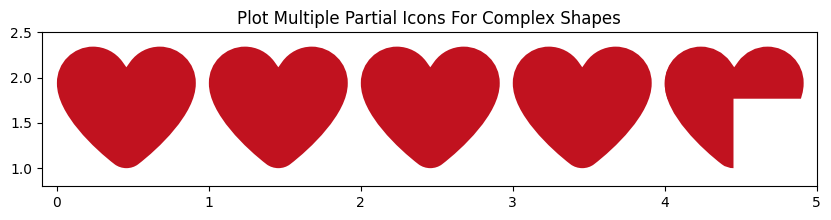

In [68]:
#| label: fig-heart-multiple
#| fig-cap: "For complex partial plots, consider drawing multiple partial icons."

# Use CreateAlignedIcon to create a path for the heart icon
path_size = 100
heart_path = CreateAlignedIcon(fa_dict['heart'], fp_solid, 0, 0, path_size)

# Define bounding boxes for clipping with x_min, y_min, x_max, y_max coordinates
bbox_top = mtransforms.Bbox.from_extents(0, 0.5*path_size, 1*path_size, 1*path_size)
bbox_left = mtransforms.Bbox.from_extents(0, 0, 0.5*path_size, 1*path_size)

# Clip the path to the Bbox
clipped_top = heart_path.clip_to_bbox(bbox_top, inside=True)
clipped_left = heart_path.clip_to_bbox(bbox_left, inside=True)

# Set the marker size
marker_size = 40000
icon_color = '#C1121F'
edge_color = 'None'

# Plot the hearts
plt.figure(figsize=(10, 2))

# Plot four full hearts
for i in range(0, 4):
    plt.scatter(i, 1, marker=heart_path2, s=marker_size, color=icon_color, edgecolors=edge_color)
    
# Plot three-quarters of a full heart_path
marker_size_top = marker_size * 1.0
marker_size_left = marker_size * 0.75
plt.scatter(4, 1, marker=clipped_top, s=marker_size_top, color=icon_color, edgecolors=edge_color)
plt.scatter(4, 1, marker=clipped_left, s=marker_size_left, color=icon_color, edgecolors=edge_color)

# Plot logistics
plt.xlim(-0.1, 5)
plt.ylim(0.8, 2.5)
plt.title('Plot Multiple Partial Icons For Complex Shapes')
plt.show()

So now we can plot part of an icon! Let's see how this feature can be used in a bar graph like visual.

### Example Bar Graph with Icons

Let's try visualizing an arbitrary dataset of commuter numbers as a bar graph-like figure. We'll show a traditional bar graph, followed by two types of icon based graphs. 

In [69]:
# Arbitrary dataset we will be visualizing
commute_data = {"walk": 6, "bicycle": 18, "car": 22, "bus": 14}

Let's start with the ordinary horizontal bar graph:

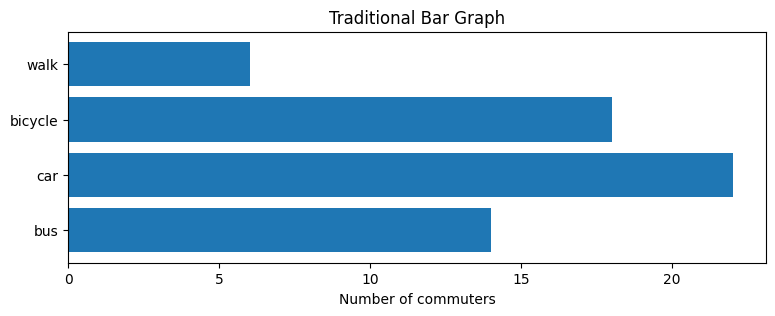

In [70]:
#| label: fig-bar-simple
#| fig-cap: "A simple horizontal bar graph representing the number of commuters in each category."

# First plot is a horizontal bar graph
fig, ax = plt.subplots()
fig.set_figheight(3)
fig.set_figwidth(9)

# Graph from top to bottom
ax.barh(commute_data.keys(), commute_data.values(), align='center')
ax.invert_yaxis()  # labels read top-to-bottom

# Graph logistics
ax.set_xlabel('Number of commuters')
ax.set_title('Traditional Bar Graph')
plt.show()

Simple, but works for most use cases. But of course we want to show off what we can now do with Font Awesome icons. 

Let's try showing the magnitude with icons instead of bars.

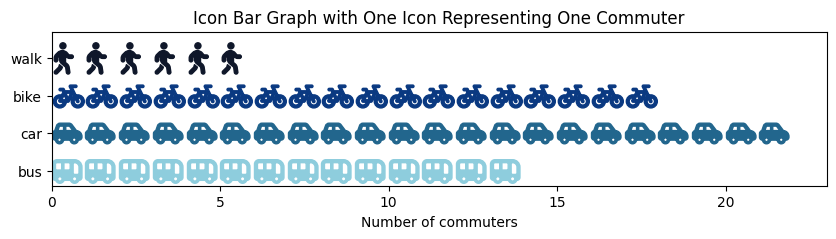

In [71]:
#| label: fig-bar-icons-busy
#| fig-cap: "Using one icon to represent one commuter can generate a busy-looking graph with small icons."
 
# Constants to use
path_size = 1
icon_size = [900, 2100, 1800, 1800]
icon_color =['#0F172A', '#0A3981', '#22668D', '#8ECDDD']

# Generate a figure
plt.figure(figsize=(10, 2))

# Plot full icons
for index, (commute_key, commute_value) in enumerate(commute_data.items()):
    for i in range(0, commute_value):
        # Find the icon to plot
        commute_icon = CreateAlignedIcon(fa_dict[commute_key], fp_solid, 0, 0.5, path_size)
        plt.scatter(i, -index, marker=commute_icon, s=icon_size[index], color=icon_color[index], edgecolors=None)

# Plot logistics
plt.xlim([0, 23])
plt.ylim([-3.4, 0.7])
plt.xlabel('Number of commuters')
plt.yticks([-3, -2, -1, 0], ['bus', 'car', 'bike', 'walk'])
plt.title('Icon Bar Graph with One Icon Representing One Commuter')
plt.show()

Not bad. However, depending on the dataset, the graph may become unmanageably long, or the icons may become small and indistinguishable. If the viewer is not able to easily see the difference between the car and bus icons, it is failing as an infographic.

A better way may be to let icons represent a group of 10 commuters, and plot partial icons. 

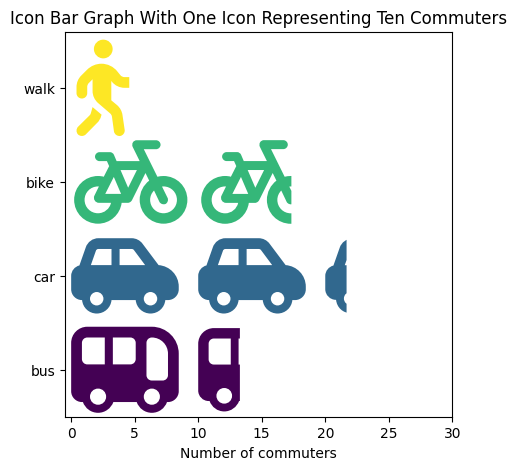

In [72]:
#| label: fig-bar-icons-big
#| fig-cap: "Using one icon to represent a group of commuters allows for the use of bigger icons, generating a cleaner graph."

# Constants to use
commuter_per_icon = 10
path_size = 100
icon_size = [12000, 28000, 24000, 24000]
partial_marker_size = [7000, 18000, 2800, 3600]
icon_color = plt.colormaps['viridis_r']([0, 0.333, 0.666, 1.0])
edge_color = 'None'

# Generate a figure
plt.figure(figsize=(5, 5), facecolor='white')

# Plot the icons
for index, (commute_key, commute_value) in enumerate(commute_data.items()):
    # Create icon
	commute_icon = CreateAlignedIcon(fa_dict[commute_key], fp_solid, 0, 0.5, path_size)
    
	# Plot the full icons
	for i in range(0, commute_value-commuter_per_icon, commuter_per_icon):
        # Plot the full icons
		plt.scatter(i, -index, marker=commute_icon, s=icon_size[index], color=icon_color[index], edgecolors=edge_color)
        
	# Plot the remaining number as a fraction
	quot_commuters, rem_commuters = divmod(commute_value, commuter_per_icon)
	frac_rem = rem_commuters / commuter_per_icon
    
	# Define bounding boxes for clipping with x_min, y_min, x_max, y_max coordinates
	bbox = mtransforms.Bbox.from_extents(0, -0.5*path_size, frac_rem*path_size, 0.5*path_size)
    
	# Clip the path to the Bbox
	clipped_path = commute_icon.clip_to_bbox(bbox, inside=True)
    
	# Plot the partial icon
	plt.scatter(quot_commuters * commuter_per_icon, -index, marker=clipped_path, s=partial_marker_size[index], color=icon_color[index], edgecolors=edge_color)

# Plot logistics
plt.xlim([-0.5, 30])
plt.ylim([-3.5, 0.6])
plt.xlabel('Number of commuters')
plt.yticks([-3, -2, -1, 0], ['bus', 'car', 'bike', 'walk'])
plt.title('Icon Bar Graph With One Icon Representing Ten Commuters')
plt.show()

By doing this, we can show much bigger icons. We can easily tell the difference between the car and bus icons. 

In the next section, we move away from the `plt.scatter()` function and add an image overlay to the icon.

## Adding an Image Overlay to Icons

Thus far in this tutorial, we've converted the Font Awesome icons into text and path objects, changed its size, color and rotation. We can even plot part of an icon using bounding boxes. 

In this section, I'll show you how to apply an image overlay on it. 

First, we need the `PIL` module to open image files.

In [73]:
# Import libraries
import PIL

Although I said that we'll apply an image overlay to the Font Awesome icon, technically speaking, that's not what we are doing. Rather, we are placing a clipping area, defined by the icon path, on top of an image, which is strategically placed within the plotting area. Here are the general steps involved:

1. Create a path to use as the clipping window with the `CreateAlignedIcon()` function
2. Open the image you'd like to clip with `PIL.Image.open()`
3. Place the image in the desired location on your plot with `ax.imshow()`
4. Calculate the transformation required to move the path created in step 1 to where the image in step 3 was placed with `mtransforms.Affine2D().translate()` function
5. Use the `.set_clip_path()` method on the output from step 3 to apply the clipping window on the image
	- Use a path object for a quick solution
	- Import the `matplotlib.patches` module and use a patch object if the icon outline needs to be drawn on the same figure

Let's place three flag images onto the plot, and clip it with the Font Awesome flag icon as paths:

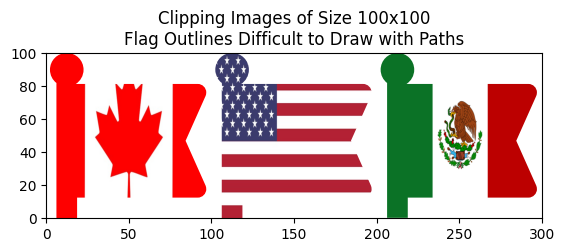

In [ ]:
#| label: fig-overlay-path
#| fig-cap: "Clipping images to size 100 by 100 px results in distortion of the details in the flag images. To draw the flag outline with paths, trial and error of marker sizes using the scatter plot is required."

# The three flag image file names
flag_filename = ['./data/canada-flag.jpg', './data/usa-flag.jpg', './data/mexico-flag.png']

# Create a flag icon to use as the clipping window
path_size = 100
flag_path = CreateAlignedIcon(fa_dict['flag'], fp_solid, 0, 0, path_size)
        
# Make a plot to draw the flags
fig, ax = plt.subplots()

# Plot the three flags one by one
for i in range(0, len(flag_filename)):
    # Open the flag image one by one with PIL.Image.open
    with PIL.Image.open(flag_filename[i]) as flag_img:
        
		# We'll set the image to be path_size x path_size in size. Note that this will distort the image
        img_x = path_size
        img_y = path_size
		
		# Place the flag image at the specified coordinates
        start_x = i * path_size
        im_now = ax.imshow(flag_img, extent=[start_x, start_x + img_x, 0, img_y])
        
		# Calculate the transformation required to move the path (positioned near the origin) to where the image is placed
        tx = i * path_size 
        ty = 0
        trans_now = mtransforms.Affine2D().translate(tx, ty) + ax.transData

		# Set the clipping path on top of the flag image
        im_now.set_clip_path(flag_path, transform=trans_now)
        
		# If you want the outline of the flag, you will need to manually play around with the marker size
        # plt.scatter(i * path_size, 0, marker=flag_path, color='None', s=56000, edgecolors='black')
        
# Plot logistics
ax.set_xlim(0, 300)
ax.set_ylim(0, 100)
ax.set_title('Clipping Images of Size 100x100\nFlag Outlines Difficult to Draw with Paths')
plt.show()

The image dimensions were set to fit within the path size, which was 100 by 100. This distorted the flag image so it looked stretched along the y axis. 

If we'd like to eliminate this distortion, we will need to figure out the original image dimensions and calculate a correction factor to adjust the size of the image to the path size. 

```
# Know the original flag image dimensions to eliminate distortion
img_width, img_height = flag_img.size

# We'll need a correction factor to keep the image undistorted
corr_fac = path_size / img_height
img_x = img_width * corr_fac
img_y = img_height * corr_fac
```

This may require additional code to center the flag image along the x axis to make sure we clip the center portion of the flag image, rather than just the left edge. 

Using a path argument on the `.set_clip_path()` method is quick because we already had the path object at hand. However, for those who want an icon outline for the image overlay, converting the path to a patch object before calling the `.set_clip_path()` method may be better choice. I'll repeat the previous flag image overlay code above using a patch object.

But first, we'll need the `matplotlib.patches` library to deal with patch type objects.

In [75]:
# Import libraries
import matplotlib.patches as mpatches

We'll replicate the flag image overlay code from above with a couple modifications.

- Original image ratio are used to eliminate the stretch-like distortion
- Flag image is adjusted along the x axis to clip out the center portion of the flag, rather than its left edge
- **Paths are converted to patches** before clipping
	- Icon outline is drawn by adding the patch to the figure with `ax.add_patch()` method

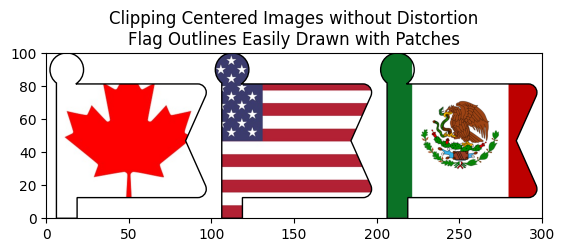

In [ ]:
#| label: fig-overlay-patches
#| fig-cap: "Clipping images at the original ratio eliminates distortion of the details in the flag images. To draw the flag outline, simply add the patch object to the plot."

# The three flag image file names
flag_filename = ['./data/canada-flag.jpg', './data/usa-flag.jpg', './data/mexico-flag.png']

# Create a flag icon to use as the clipping window
path_size = 100
flag_path = CreateAlignedIcon(fa_dict['flag'], fp_solid, 0, 0, path_size)
        
# Make a plot to draw the flags
fig, ax = plt.subplots()

# Plot the three flags one by one
for i in range(0, len(flag_filename)):
    # Open the flag image one by one with PIL.Image.open
    with PIL.Image.open(flag_filename[i]) as flag_img:
        
		# Know the original flag image dimensions to eliminate distortion
        img_width, img_height = flag_img.size
        
		# We'll need a correction factor to keep the image undistorted
        corr_fac = path_size / img_height
        img_x = img_width * corr_fac
        img_y = img_height * corr_fac
        # img_x = path_size # If you don't care for distortion, you can use these
        # img_y = path_size 
		
		# Place the flag image at the specified coordinates
        start_x = i * path_size - (img_x - path_size) / 2 # Centers the image on the flag path along the x axis
        im_now = ax.imshow(flag_img, extent=[start_x, start_x + img_x, 0, img_y])
        
		# Calculate the transformation required to move the path (positioned near the origin) to where the image is placed
        tx = i * path_size 
        ty = 0
        trans_now = mtransforms.Affine2D().translate(tx, ty) + ax.transData

		# Convert the path to a patch before clipping
        flag_patch = mpatches.PathPatch(flag_path, transform=trans_now)   # keep patch transform
        im_now.set_clip_path(flag_patch)
        
		# Draw the flag outline using the flag_patch
        ax.add_patch(flag_patch)
        flag_patch.set_facecolor('None')
        
# Plot logistics
ax.set_xlim(0, 300)
ax.set_ylim(0, 100)
ax.set_title('Clipping Centered Images without Distortion\nFlag Outlines Easily Drawn with Patches')
plt.show()

Fixing the distortion issue and centering the flag image on the icon path had introduced a new issue. Namely, the red edges of the Canadian flag disappeared. We see that it greatly benefits from adding an icon outline to define the edges. 

Previously, when we used paths to clip the image, we could draw the outline using `plt.scatter()` with a `edgecolors='black'` and `color='None'`. However, the marker size had to be figured out through trial and error:

```
# If you want the outline of the flag, you will need to manually play around with the marker size
plt.scatter(i * path_size, 0, marker=flag_path, color='None', s=56000, edgecolors='black')
```        

On the other hand, when we used patch objects, we could easily draw it like so:

```
# Draw the flag outline using the flag_patch
ax.add_patch(flag_patch)
flag_patch.set_facecolor('None')
```

No manual search for the perfect marker size needed. 

Of course, if you've already set up your code to clip your images using paths, you can apply the transformations to make the patch object just for drawing the outlines. 

## Summary

In this blog post, you learned how to 

- Display Font Awesome icons using `matplotlib`'s `.text()` method with your desired position, size, color, rotation and icon alignment
- Draw the icons as path objects with `matplotlib`'s `.scatter()` method with the additional features of
	- Different colors for the face and edges of the icon
	- Greater precision in horizontal and vertical alignment possible with the provided `CreateAlignedIcon()` function
- Draw just part of an icon using bounding boxes created with `matplotlib.transforms.Bbox.from_extents()` and clipping the path using the `.clip_to_bbox()` method
- Clip images to the icon shape using `.set_clip_path()` method to get an image overlay type effect
	- Use patch objects to easily draw icon outlines


Here is a table summarizing the features that can be implemented when displaying the icons as text objects or path objects.

|Feature|Icons as Text|Icons as Paths|
|-----|-----|-----|
|Change icon size| ✅ | ✅|
|Change icon color| ✅ | ✅|
|Change icon edge color| ❌ |✅ (not recommended for part of an icon)|
|Rotate icon| ✅|✅|
|Specify horizontal and vertical alignments | ✅ (fifteen possible combinations)|✅ (precise manipulation possible)|
|Show only part of an icon|❌|✅ (cannot be combined with edge color feature)|
|Image overlay on icon|❌|✅ (conversion to patch objects has additional benefits)|

Happy icon plotting!

## Further Readings

- Under construction